# Impact Analysis with Life-like network automata

This Notebook refers to the manuscript `impact_analysis.tex`

In [16]:
import gc # import garbage collector

from matplotlib import pyplot as plt

import glob
import re

import seaborn as sns
import pandas as pd

import numpy as np
import cellpylib as cpl
import igraph as ig
import h5py

import torch as tc

from matplotlib import rcParams

from tqdm import tqdm

# Configure matplotlib backend for stability
import matplotlib

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "figure.dpi": 100,
    "savefig.dpi": 300,
})

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.automata import LLNA
from src.simulation import *

from src.analysis import mean_field_slope, init_config_with_dens, switch_life_to_higher_node_property_values, hamming_weight, boolean_sens, mean_field_dens_propagation, derrida_map_analytical,shannon_entropy
from src.rules import return_life_like_dict, return_equivalent_rule, binary_indices
from src.networks import create_2d_torus_lattice, watts_strogatz_rewire
from src.visual import get_ugent_colors_dict

life_like_dict = return_life_like_dict()

figures_dir = './figures/impact_analysis/'

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Introduction

- Background and rationale of the work
- Existing approaches
- Our research question

## Definitions

### Definition of the small world network

In [2]:
# various networks have different distributions of centrality measures on their nodes

# Create a small-world network using the Watts-Strogatz model

# Parameters
width = 30                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast. 200 takes 10 minutes
num_nodes = width**2
rewiring_prob = 0.2         # Rewiring probability
p_string = f"{rewiring_prob:.2f}".replace('.', 'p')
degree = 8
num_edges = num_nodes*degree//2

# Create toroidal lattice and rewire.
lattice_graph = create_2d_torus_lattice(width, degree=degree)
small_world_graph = watts_strogatz_rewire(lattice_graph, rewiring_prob)

small_world_graph.to_directed()
small_world_edges = tc.tensor(small_world_graph.get_edgelist()).T
small_world_graph.to_undirected()

In [33]:
def node_h_indices(g):
    """Calculate h-index for each node in the graph."""
    h_indices = []
    
    for node in range(g.vcount()):
        # Get neighbors of this node
        neighbors = g.neighbors(node)
        
        # Get degrees of neighbors
        neighbor_degrees = [g.degree(n) for n in neighbors]
        
        # Sort in descending order
        neighbor_degrees_sorted = sorted(neighbor_degrees, reverse=True)
        
        # Calculate h-index for this node
        h = 0
        for i, degree in enumerate(neighbor_degrees_sorted, 1):
            if degree >= i:
                h = i
            else:
                break
        
        h_indices.append(h)
    
    return h_indices

In [4]:
# Get basic network properties
print(f"Network: {small_world_graph.vcount()} nodes, {small_world_graph.ecount()} edges")

# Compute degree distribution instead (much faster and safer)
degrees = small_world_graph.degree()
avg_neigh_degree = small_world_graph.knn()[0]
h_index = node_h_indices(small_world_graph)
eigenvector = small_world_graph.eigenvector_centrality()
betweenness = small_world_graph.betweenness()
closeness = small_world_graph.closeness()

Network: 900 nodes, 3600 edges


Plot created successfully
Garbage collected: 22402 objects


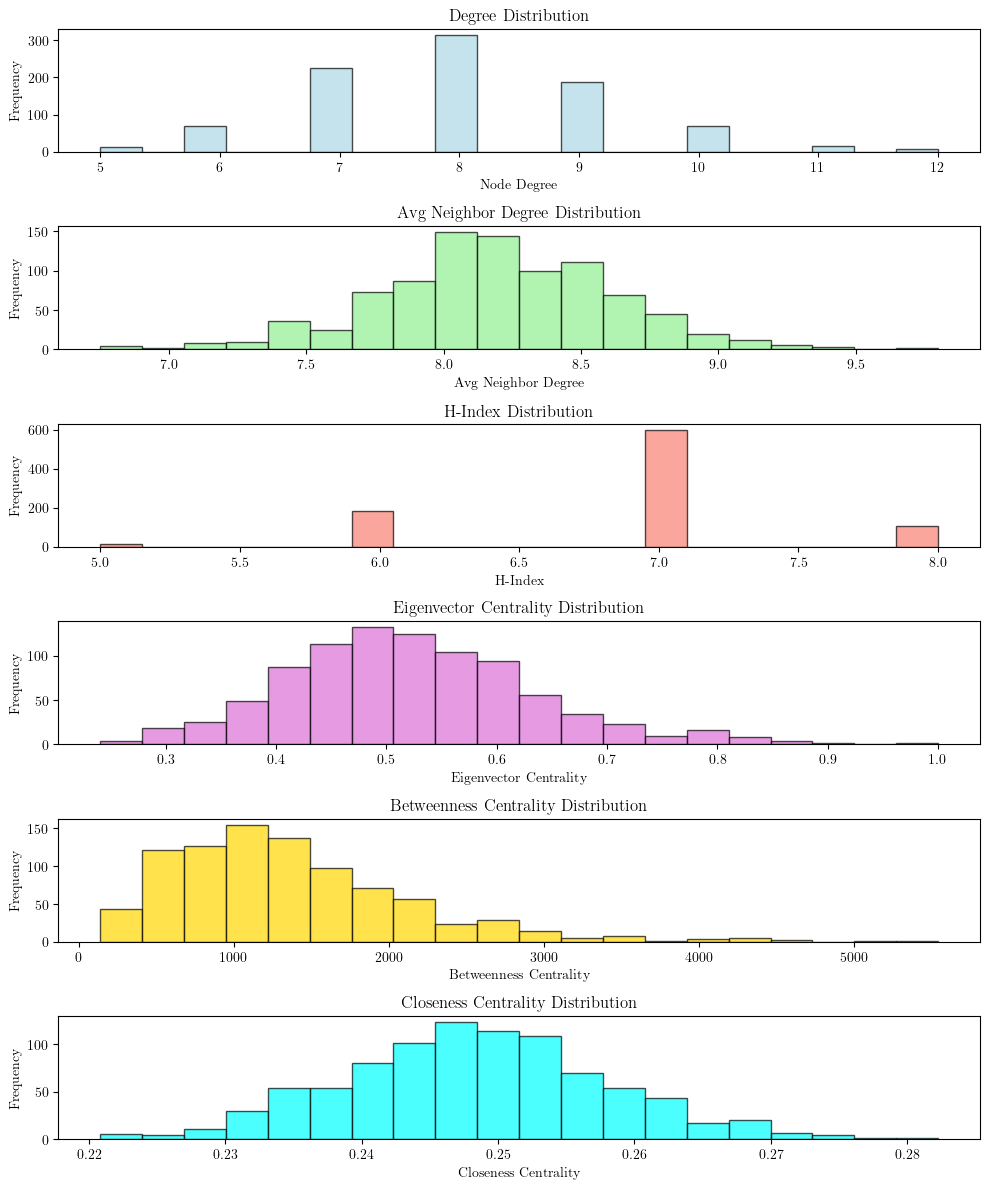

In [6]:
# Create a simple plot
fig, axs = plt.subplots(6, 1, figsize=(10, 12))

# degree
axs[0].hist(degrees, bins=20, color='lightblue', edgecolor='black', alpha=0.7)
axs[0].set_xlabel('Node Degree')
axs[0].set_ylabel('Frequency')
axs[0].set_title('Degree Distribution')

# avg neighbor degree
axs[1].hist(avg_neigh_degree, bins=20, color='lightgreen', edgecolor='black', alpha=0.7)
axs[1].set_xlabel('Avg Neighbor Degree')
axs[1].set_ylabel('Frequency')
axs[1].set_title('Avg Neighbor Degree Distribution')

# do the same for h-index
axs[2].hist(h_index, bins=20, color='salmon', edgecolor='black', alpha=0.7)
axs[2].set_xlabel('H-Index')
axs[2].set_ylabel('Frequency')
axs[2].set_title('H-Index Distribution')

# do the same for eigenvector centrality
axs[3].hist(eigenvector, bins=20, color='orchid', edgecolor='black', alpha=0.7)
axs[3].set_xlabel('Eigenvector Centrality')
axs[3].set_ylabel('Frequency')
axs[3].set_title('Eigenvector Centrality Distribution')

# repeat for betweenness
axs[4].hist(betweenness, bins=20, color='gold', edgecolor='black', alpha=0.7)
axs[4].set_xlabel('Betweenness Centrality')
axs[4].set_ylabel('Frequency')
axs[4].set_title('Betweenness Centrality Distribution')

# and for closeness
axs[5].hist(closeness, bins=20, color='cyan', edgecolor='black', alpha=0.7)
axs[5].set_xlabel('Closeness Centrality')
axs[5].set_ylabel('Frequency')
axs[5].set_title('Closeness Centrality Distribution')

# axs[2].hist(h_index, bins=20, color='salmon', edgecolor='black', alpha=0.7)
plt.tight_layout()

print("Plot created successfully")

collected = gc.collect()
print(f"Garbage collected: {collected} objects")

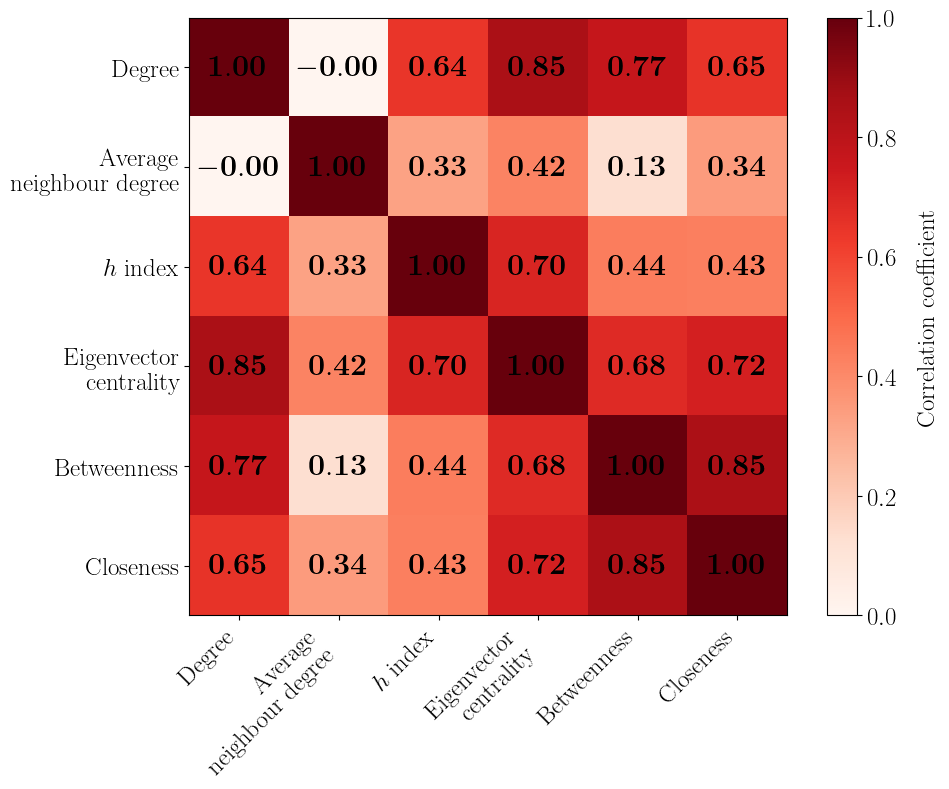

In [7]:
# Combine all metrics into a single array
metrics = np.column_stack([degrees, avg_neigh_degree, h_index, eigenvector, betweenness, closeness])
metric_names = ['Degree', 'Average\nneighbour degree', r'$h$ index', 'Eigenvector\ncentrality', 'Betweenness', 'Closeness']

# Calculate correlation matrix
corr_matrix = np.corrcoef(metrics.T)

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
fontsize = 18

cmap = 'Reds'
im = ax.imshow(corr_matrix, cmap=cmap, vmin=0, vmax=1)

# Set ticks and labels
ax.set_xticks(np.arange(len(metric_names)))
ax.set_yticks(np.arange(len(metric_names)))
ax.set_xticklabels(metric_names, rotation=45, ha='right')
ax.set_yticklabels(metric_names)

# increase fontsize of tick labels
ax.tick_params(axis='both', which='major', labelsize=fontsize)

# increase tick label size of colorbar
cbar = plt.colorbar(im, ax=ax, label='Correlation coefficient')
cbar.ax.tick_params(labelsize=fontsize)
cbar.ax.yaxis.label.set_fontsize(fontsize)
# move label to the right a bit
# cbar.ax.yaxis.set_label_position('right')
cbar.ax.yaxis.labelpad = 15

# Add correlation values to cells
for i in range(len(metric_names)):
    for j in range(len(metric_names)):
        text = ax.text(j, i, r'$\mathbf{' + f'{corr_matrix[i, j]:.2f}' + r'}$',
                      ha="center", va="center", color="black", fontsize=fontsize+4)

# plt.title('Correlation Matrix of Network Centrality Measures')
plt.tight_layout()
# plt.savefig(figures_dir+f'correlation_matrix_centrality_measures_width{width}_degree{degree}_p{p_string}.pdf')
plt.show()

_ = gc.collect()

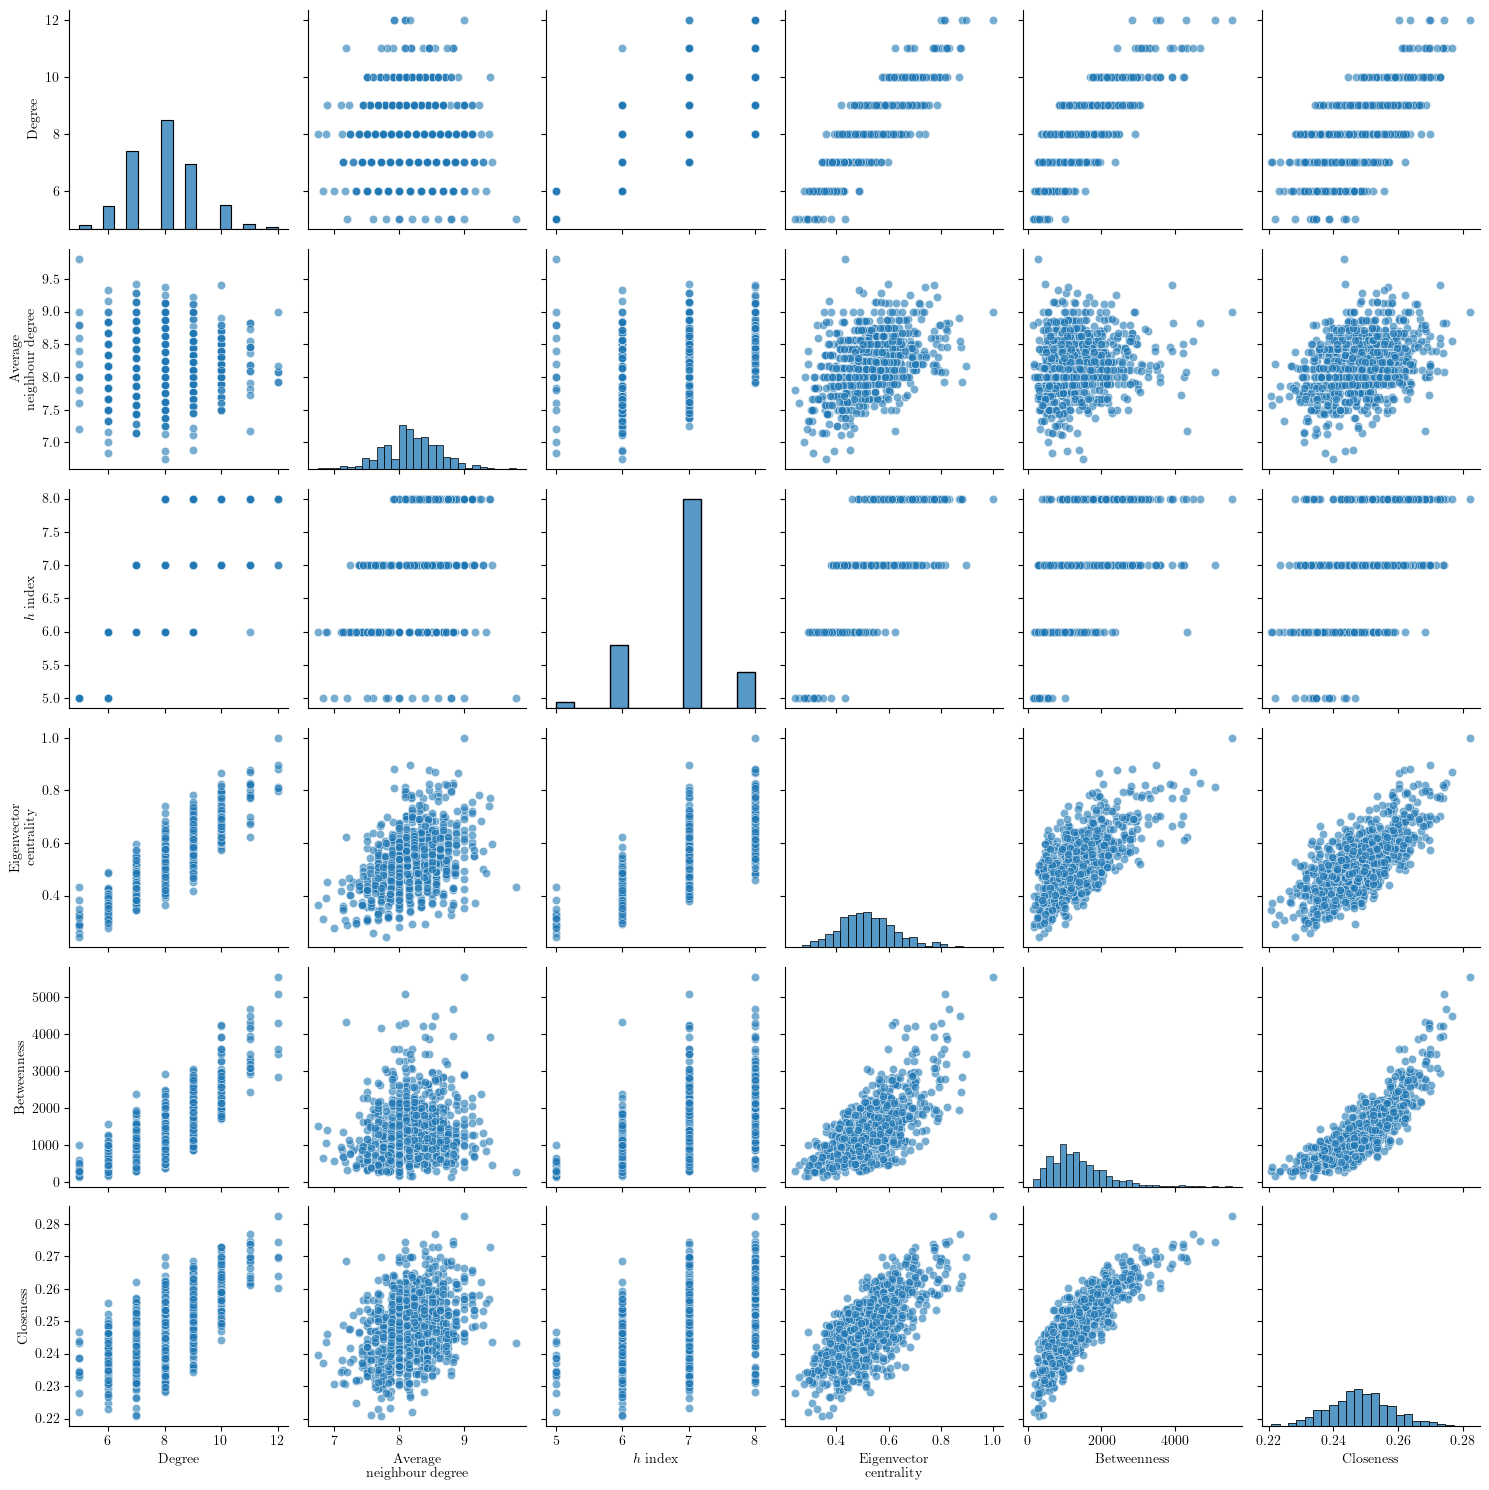

In [8]:
# Create dataframe
df = pd.DataFrame(metrics, columns=metric_names)

# Create pairplot
sns.pairplot(df, diag_kind='hist', plot_kws={'alpha': 0.6})
plt.tight_layout()
plt.show()

### Definition of the LLNA

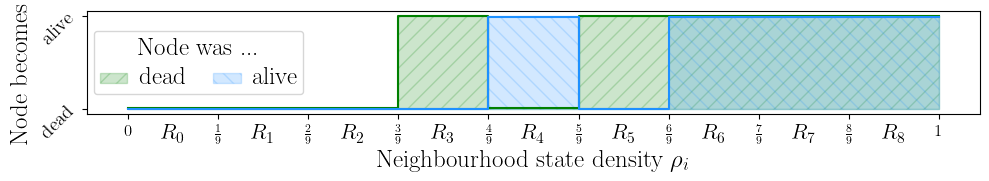

In [13]:
SAVEFIG = False

resolution = 9

# GoL as LLNA model
beta = 488
sigma = 464
born_if = binary_indices(beta)
survive_if = binary_indices(sigma)
model = LLNA(resolution, x=born_if, y=survive_if, iso=True)

# plot both diagrams
fig, ax = plt.subplots(1,1,figsize=(10,1.9))
model.diagram(ax=ax)

# delete separate ax labels
size=18
ax.set_xlabel(fr'Neighbourhood state density $\rho_i$', fontsize=size)
ax.set_ylabel(fr'Node becomes', fontsize=size, y=0.4)
# ax.set_title(fr"Local update rule diagram for {model.__str__(latex=True)} (the Game of Life)", fontsize=size)
ax.set_title(None)

ax.set_xticks(np.linspace(0,1,2*resolution+1))
ax.set_xticklabels([f'$0$', f'$R_0$',
                    f'$\\frac{1}{9}$', f'$R_1$',
                    f'$\\frac{2}{9}$', f'$R_2$',
                    f'$\\frac{3}{9}$', f'$R_3$',
                    f'$\\frac{4}{9}$', f'$R_4$',
                    f'$\\frac{5}{9}$', f'$R_5$',
                    f'$\\frac{6}{9}$', f'$R_6$',
                    f'$\\frac{7}{9}$', f'$R_7$',
                    f'$\\frac{8}{9}$', f'$R_8$', f'$1$'])

ticks = ax.xaxis.get_major_ticks()
for i, tick in enumerate(ticks):
    if i % 2 == 1:
        tick.tick1line.set_markersize(0)

# ax.set_xticklabels(ax.get_xticklabels(), fontsize=size-4)
ax.set_yticklabels(ax.get_yticklabels(), fontsize=size-4)

xticklabels = ax.get_xticklabels()
for i, label in enumerate(xticklabels):
    if i % 2 == 1:
        label.set_fontsize(size-2)
    else:
        label.set_fontsize(size-6)

legend = ax.legend(ncol=2, loc='center left')
legend.set_title("Node was ...", prop={'size': size})
for text in legend.get_texts():
    text.set_fontsize(size)  # Change legend font size

fig.tight_layout()

savename = f'llna_diagram-rule_r{resolution}s{sigma}b{beta}.jpg'

if SAVEFIG:
    plt.savefig(figures_dir+f'{savename}', bbox_inches='tight', dpi=1200)

### Definition of HW and BS

## Methods

### Structural ranking

100%|██████████| 200/200 [00:00<00:00, 372.54it/s]


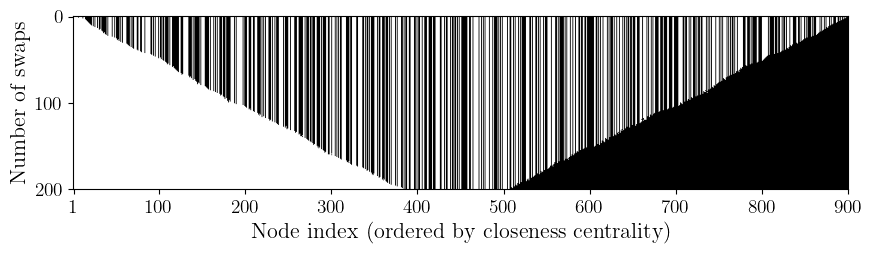

In [100]:
SAVEFIG = False

init_dens = .5
init_config = init_config_with_dens(num_nodes, init_dens)

total=200
node_property_name = "closeness centrality"
node_property_values = np.array(closeness) # np.random.permutation(num_nodes)
kill_low_values = True

return_sorted_values = True

init_config_stack = init_config.copy()
for number_of_switches in tqdm(range(total), total=total):
    init_config_switched, sorted_values = switch_life_to_higher_node_property_values(node_property_values, init_config, number_of_switches, kill_low_values=kill_low_values, return_sorted_values=return_sorted_values)
    init_config_stack = np.vstack((init_config_stack, init_config_switched))

init_config_stack_ordered = init_config_stack[:,np.argsort(node_property_values)]

fig, ax = plt.subplots(1,1,figsize=(10,4))
ax.imshow(init_config_stack_ordered, cmap='Greys')

# ax.set_title(f'Initial configurations ordered by {node_property_name}', fontsize=18)
ax.set_xlabel(f'Node index (ordered by {node_property_name})', fontsize=16)
ax.set_ylabel('Number of swaps', fontsize=16)

# change ticklabelsize
ax.tick_params(axis='both', which='major', labelsize=14)

# change labels from 0-899 to 1-900
ax.set_xticks([0, 99, 199, 299, 399, 499, 599, 699, 799, 899])
ax.set_xticklabels([1, 100, 200, 300, 400, 500, 600, 700, 800, 900])

if SAVEFIG:
    plt.savefig(figures_dir+f'initial_configurations_ordered_by_{node_property_name.replace(" ", "_").lower()}_width{width}_degree{degree}_p{p_string}.pdf', bbox_inches='tight')

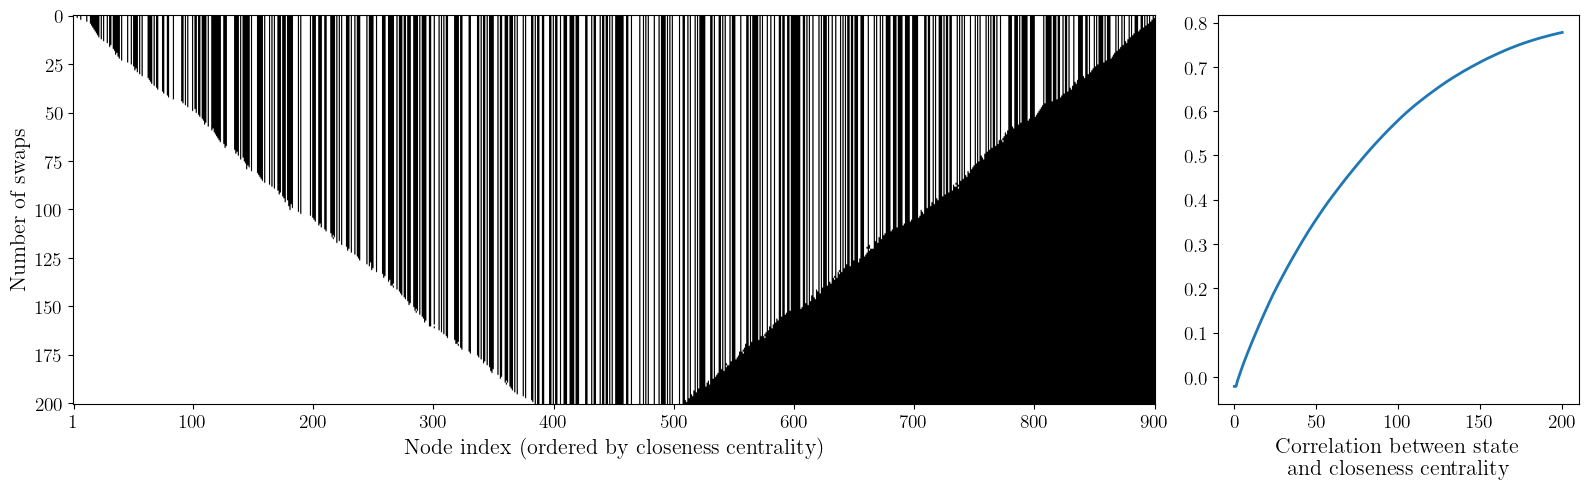

In [115]:
# may also be interesting to show correlation evolution
SAVEFIG = False

closeness_repeated = np.tile(sorted_values, (total+1, 1))

correlations = np.array([np.corrcoef(init_config_stack_ordered[k], closeness_repeated[k])[0, 1] for k in range(total+1)])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5), gridspec_kw={'width_ratios': [3, 1]})

# Left: imshow
ax1.imshow(init_config_stack_ordered, cmap='Greys', aspect='auto')
ax1.set_xlabel(f'Node index (ordered by {node_property_name})', fontsize=16)
ax1.set_ylabel('Number of swaps', fontsize=16)
ax1.tick_params(axis='both', which='major', labelsize=14)
ax1.set_xticks([0, 99, 199, 299, 399, 499, 599, 699, 799, 899])
ax1.set_xticklabels([1, 100, 200, 300, 400, 500, 600, 700, 800, 900])

# Right: correlation plot
ax2.plot(correlations, linewidth=2)
ax2.set_xlabel('Correlation between state\nand closeness centrality', fontsize=16)
# ax2.set_ylabel('Correlation between state\nand closeness centrality', fontsize=16)
ax2.tick_params(axis='both', which='major', labelsize=14)
# ax2.grid(True, alpha=0.3)

plt.tight_layout()

if SAVEFIG:
    plt.savefig(figures_dir+f'initial_configurations_and_correlation_ordered_by_{node_property_name.replace(" ", "_").lower()}_width{width}_degree{degree}_p{p_string}.pdf', bbox_inches='tight')

### Node pinning

## Results and Discussion

### Eligible LLNAs

_Finding the rules that obey the demands_

In [2]:
# find the rules that obey the self-equivalence condition (from tuple_finder_production.py from Claude)

def reverse_bits(n, r):
    result = 0
    for i in range(r):
        if n & (1 << i):
            result |= (1 << (r - 1 - i))
    return result


def find_tuples(r):
    if r % 2 == 0:
        raise ValueError(f"r must be odd, got r={r}")
    
    mask = (1 << r) - 1  # Precompute: 2^r - 1 (all bits set)
    
    for sigma in range(1 << r):  # Iterate 0 to 2^r - 1
        reversed_sigma = reverse_bits(sigma, r)
        beta = mask ^ reversed_sigma  # XOR = complement
        yield (beta, sigma)

def find_tuples_list(r):
    return list(find_tuples(r))

resolution = 17
self_equiv_rule_list = find_tuples_list(resolution)

len(self_equiv_rule_list)

131072

In [3]:
### find the rules that obey the mean-field curve conditions

# half of the rules can be filtered because they are not legal (0 does not map to 0)
legal_self_equiv_rule_list = []
for beta, sigma in self_equiv_rule_list:
    if beta%2 == 0:
        legal_self_equiv_rule_list.append((beta, sigma))

len(legal_self_equiv_rule_list)

65536

[ True  True  True  True  True  True False False False False False False
 False False False False]


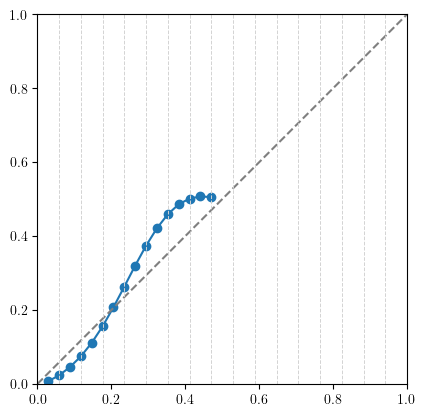

In [4]:
# we create the mean-field density propagation curve based on the resolution (only needs a limited number of points)
# exlude the outer point (as these are already accounted for)
# by construction, the upper half of the density values are symmetric to the lower half
low_dens_array = np.linspace(0,.5,resolution+1)[1:-1]
degree = 11

# pick random tuple from list
(beta, sigma) = legal_self_equiv_rule_list[np.random.randint(len(legal_self_equiv_rule_list))]

B_set = binary_indices(beta)
S_set = binary_indices(sigma)

low_mfdp = mean_field_dens_propagation(resolution, B_set=B_set, S_set=S_set, current_dens=low_dens_array, degree=degree)

print(low_mfdp < low_dens_array)

plt.plot(low_dens_array, low_mfdp, marker='o')
plt.plot([0,1], [0,1], linestyle='--', color='gray')

# square the plot visually
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(0, 1)
plt.ylim(0, 1)

for i in range(resolution):
    plt.axvline(x=i/resolution, color='lightgray', linestyle='--', linewidth=0.7)

In [6]:
RUN_AGAIN = False

if RUN_AGAIN:

    degrees = np.arange(4,13)

    print(f"Resolution {resolution}:")
    print()

    for degree in degrees:
        # run over all legal self-equivalent rules and check which obey the condition
        totalitarian_rules = []

        for beta,sigma in tqdm(legal_self_equiv_rule_list, total=len(legal_self_equiv_rule_list)):
            B_set = binary_indices(beta)
            S_set = binary_indices(sigma)
            low_mfdp = mean_field_dens_propagation(resolution, B_set=B_set, S_set=S_set, current_dens=low_dens_array, degree=degree)
            # also saves the edge cases where the mf is on the first bisector
            if np.any(low_mfdp > low_dens_array):
                continue
            totalitarian_rules.append((beta, sigma))

        print(f"Found {len(totalitarian_rules)} totalitarian rules out of {len(legal_self_equiv_rule_list)} legal self-equivalent rules.")

        print(f"Saving totalitarian rules for degree {degree} and resolution {resolution} ...")
        np.save(f'data/totalitarian_rules/totalitarian_rules_resolution{resolution}_degree{degree}.npy', np.array(totalitarian_rules))

In [5]:
# pick random tuple from list
(beta, sigma) = totalitarian_rules[np.random.randint(len(totalitarian_rules))]

B_set = binary_indices(beta)
S_set = binary_indices(sigma)

current_dens = np.linspace(0,1,101)
mfdp = mean_field_dens_propagation(resolution, B_set=B_set, S_set=S_set, current_dens=current_dens, degree=degree)

plt.plot(current_dens, mfdp)
plt.plot([0,1], [0,1], linestyle='--', color='gray')

# square the plot visually
plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(0, 1)
plt.ylim(0, 1)

for i in range(resolution):
    plt.axvline(x=i/resolution, color='lightgray', linestyle='--', linewidth=0.7)

NameError: name 'totalitarian_rules' is not defined

_Find the intersection of rules for every resolution_

It appears that the set of rules that obey both demands is independent of the degree for which the mean-field curve is calculated! This will however _not_ be the case for the Boolean sensitivity (this is highly dependent on the degree).

In [7]:
resolution = 9
degrees = np.arange(4, 13, 1)

init_degree = 4
totalitarian_rules = np.load(f'data/totalitarian_rules/totalitarian_rules_resolution{resolution}_degree{init_degree}.npy')
totalitarian_rules_set = set(map(tuple, totalitarian_rules))

print(f"Resolution {resolution}.")
print()
print(f"Size of the set for degree {init_degree}: {len(totalitarian_rules_set)}")

for degree in degrees[1:]:
    totalitarian_rules = np.load(f'data/totalitarian_rules/totalitarian_rules_resolution{resolution}_degree{degree}.npy')
    totalitarian_rules_set = totalitarian_rules_set.intersection(set(map(tuple, totalitarian_rules)))

print(f"Size of the intersection for all degrees: {len(totalitarian_rules_set)}")

Resolution 9.

Size of the set for degree 4: 64
Size of the intersection for all degrees: 12


_Mean-field curve and Derrida curve for rule_ $\phi^9_{192,505}$

Using rule (beta=192, sigma=505)


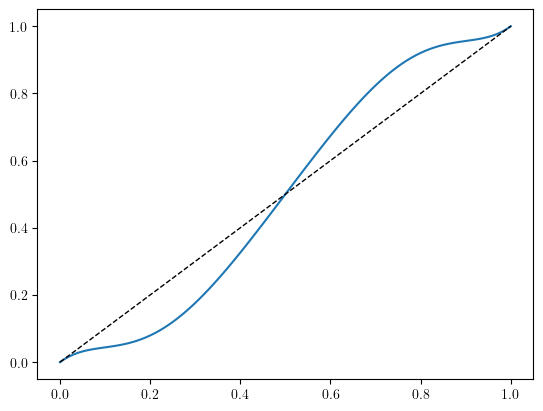

In [8]:
rho0_array = np.linspace(0,1,101)
degrees= np.arange(4,13,1, dtype=int)

resolution = 9
beta = 192
sigma = 505

# beta, sigma = list(totalitarian_rules_set)[np.random.randint(len(totalitarian_rules_set))]
print(f"Using rule (beta={beta}, sigma={sigma})")

B_set = binary_indices(beta)
S_set = binary_indices(sigma)

rho1_arrays = np.array([mean_field_dens_propagation(resolution, B_set, S_set, rho0_array, degree) for degree in degrees])

plt.plot(rho0_array, mean_field_dens_propagation(resolution, B_set, S_set, rho0_array, 9))
plt.plot([0,1], [0,1], lw=1, ls='--', color='k')

100%|██████████| 9/9 [00:03<00:00,  2.92it/s]


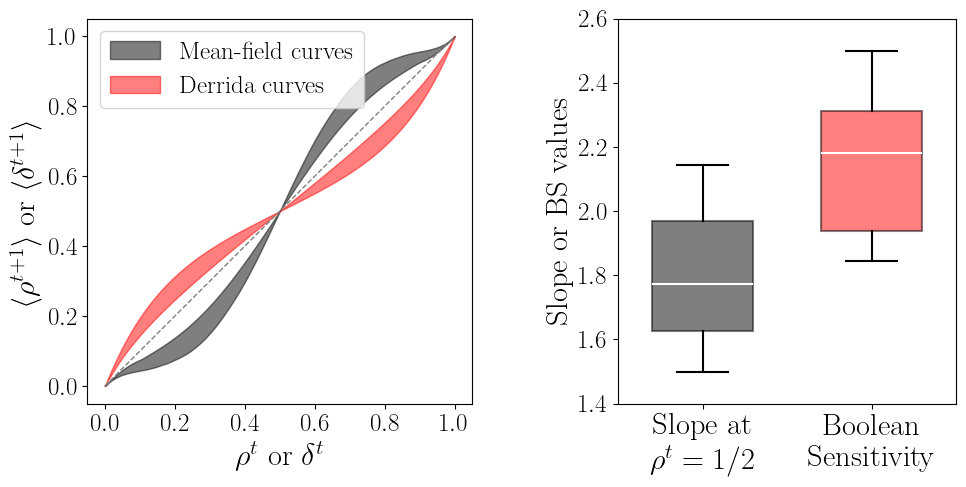

In [9]:
SAVEFIG = False

# create the LLNA
resolution = 9
degrees = np.arange(4,13)
beta = 192
sigma = 505

B_set = binary_indices(beta)
S_set = binary_indices(sigma)

ls_list = ['--', '-.']
default_colors = np.array((plt.rcParams['axes.prop_cycle'].by_key()['color']))
color_list = ['k', 'k'] #  default_colors[1:3]

# mean field curve and HW values
num_dens_points = 101
current_dens = np.linspace(0,1,num_dens_points)
next_dens_list = []
slope_list = []
for degree in tqdm(degrees, total=len(degrees)):
    # mean field curve
    next_dens = mean_field_dens_propagation(resolution, B_set, S_set, current_dens, degree)
    next_dens_list.append(next_dens)
    # Hamming weight
    slope = mean_field_slope(resolution, B_set, S_set, degree)
    slope_list.append(slope)
next_dens_array = np.array(next_dens_list)

# take minima and maxima
min_next_dens = np.min(next_dens_array, axis=0)
max_next_dens = np.max(next_dens_array, axis=0)


# Derrida plot and BS value
init_config_dens = 0.5
num_delta_points = 101
current_deltas = np.linspace(0, 1, num_delta_points)
next_deltas_list = []
BS_list = []
for degree in tqdm(degrees, total=len(degrees)):
    # Derrida plot
    next_deltas = derrida_map_analytical(resolution, B_set, S_set, current_deltas, degree, init_config_dens=init_config_dens)
    next_deltas_list.append(next_deltas)
    # Boolean sensitivity
    BS = boolean_sens(resolution, B_set, S_set, degree, norm_degree=False)
    BS_list.append(BS)
next_deltas_array = np.array(next_deltas_list)

# take minima and maxima
min_next_deltas = np.min(next_deltas_array, axis=0)
max_next_deltas = np.max(next_deltas_array, axis=0)


# create ax object
fig, axs = plt.subplots(1,2,figsize=(12,5), width_ratios=[3,2])
fontsize = 22

axs[0].fill_between(current_dens, min_next_dens, max_next_dens, color='black', alpha=0.5, label='Mean-field curves')
axs[0].fill_between(current_deltas, min_next_deltas, max_next_deltas, color='red', alpha=0.5, label='Derrida curves')
axs[0].plot([0,1], [0,1], color='gray', lw=1, ls='--')

# force square axes ratio
axs[0].set_aspect('equal', adjustable='box')

# label axes
axs[0].set_ylabel(fr"$\langle \rho^{{t+1}}\rangle$ or $\langle \delta^{{t+1}}\rangle$", size=fontsize)
axs[0].set_xlabel(fr"$\rho^t$ or $\delta^t$", size=fontsize)

axs[0].set_xticks([0, .2, .4, .6, .8, 1])
axs[0].set_yticks([0, .2, .4, .6, .8, 1])
axs[0].tick_params(axis='both', which='major', labelsize=fontsize-4)

# add a legend
axs[0].legend(fontsize=fontsize-4)


# create boxplots for slope and BS values
bp1 = axs[1].boxplot(slope_list, positions=[1], widths=0.6, patch_artist=True)
for patch in bp1['boxes']:
    patch.set_facecolor('black')
    patch.set_alpha(0.5)
for line in bp1['whiskers'] + bp1['caps'] + bp1['medians'] + bp1['boxes'] + bp1['fliers']:
    line.set_linewidth(1.5)
for median in bp1['medians']:
    median.set_color('white')

bp2 = axs[1].boxplot(BS_list, positions=[2], widths=0.6, patch_artist=True)
for patch in bp2['boxes']:
    patch.set_facecolor('red')
    patch.set_alpha(0.5)
for line in bp2['whiskers'] + bp2['caps'] + bp2['medians'] + bp2['boxes'] + bp2['fliers']:
    line.set_linewidth(1.5)
for median in bp2['medians']:
    median.set_color('white')

axs[1].set_ylim(1.4, 2.6)
axs[1].set_xticks([1, 2])
axs[1].set_xticklabels([fr'Slope at{chr(10)}$\rho^t=1/2$', 'Boolean\nSensitivity'], fontsize=fontsize)
axs[1].tick_params(axis='y', which='major', labelsize=fontsize-4)

axs[1].set_ylabel('Slope or BS values', fontsize=fontsize)

if SAVEFIG:
    plt.savefig(figures_dir+f'mfc_dc-slope_bs-rule_r{resolution}b{beta}s{sigma}.pdf', bbox_inches='tight')


<Axes: title={'center': 'Diagram for LLNA $\\phi^{9}_{192,505}$'}, xlabel="State density $\\rho$ of the node's neighbourhood", ylabel='Node becomes ...'>

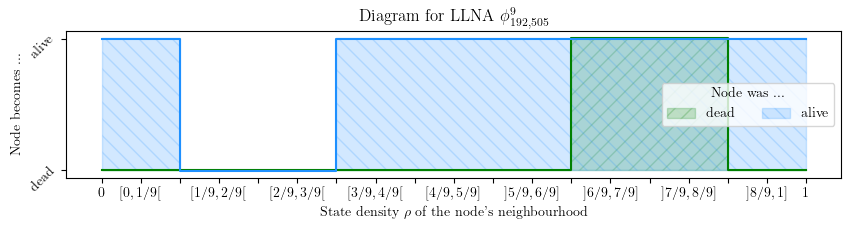

In [16]:
# create diagram for the displayed rule
resolution = 9
beta = 192
sigma = 505
B_set = binary_indices(beta)
S_set = binary_indices(sigma)
model = LLNA(resolution, x=B_set, y=S_set, iso=True)
fig, ax = plt.subplots(1,1,figsize=(10,1.9))
model.diagram(ax=ax)

_Scatter all rules, showing the spread of slope and BS_

In [26]:
resolution = 9
degrees = np.arange(4, 13, 1)

init_degree = 4
totalitarian_rules = np.load(f'data/totalitarian_rules/totalitarian_rules_resolution{resolution}_degree{init_degree}.npy')
totalitarian_rules_set = set(map(tuple, totalitarian_rules))

set_intersection = totalitarian_rules_set.copy()
set_union = totalitarian_rules_set.copy()

print(f"Resolution {resolution}.")
print()
print(f"Size of the set for degree {init_degree}: {len(totalitarian_rules_set)}")

for degree in degrees[1:]:
    totalitarian_rules = np.load(f'data/totalitarian_rules/totalitarian_rules_resolution{resolution}_degree{degree}.npy')
    set_intersection = set_intersection.intersection(set(map(tuple, totalitarian_rules)))
    set_union = set_union.union(set(map(tuple, totalitarian_rules)))

print(f"Size of the intersection for all degrees: {len(set_intersection)}")
print(f"Size of the union for all degrees: {len(set_union)}")

Resolution 9.

Size of the set for degree 4: 64
Size of the intersection for all degrees: 12
Size of the union for all degrees: 106


In [131]:
bs_list = []
mfs_list = []

bs_list_intersection = []
mfs_list_intersection = []

rule_mfs_dict = { rule: [] for rule in set_union }
rule_bs_dict = { rule: [] for rule in set_union }

rule_mfs_dict_intersection = { rule: [] for rule in set_intersection }
rule_bs_dict_intersection = { rule: [] for rule in set_intersection }

for degree in tqdm(degrees, total=len(degrees)):
    totalitarian_rules = np.load(f'data/totalitarian_rules/totalitarian_rules_resolution{resolution}_degree{degree}.npy')
    for beta, sigma in totalitarian_rules:
        # find B and S sets
        B_set = binary_indices(beta)
        S_set = binary_indices(sigma)
        # get boolean sensitivity and mean-field slope
        bs = boolean_sens(resolution, B_set=B_set, S_set=S_set, degree=degree)
        mfs = mean_field_slope(resolution, B_set=B_set, S_set=S_set, degree=degree)
        # add values to the dict
        rule = (beta, sigma)
        rule_bs_dict[rule].append(bs)
        rule_mfs_dict[rule].append(mfs)

# take medians, mins and maxs for each rule
for rule in rule_bs_dict.keys():
    bs_values = rule_bs_dict[rule]
    mfs_values = rule_mfs_dict[rule]
    bs_median = np.median(bs_values)
    mfs_median = np.median(mfs_values)
    bs_min = np.min(bs_values)
    mfs_min = np.min(mfs_values)
    bs_max = np.max(bs_values)
    mfs_max = np.max(mfs_values)
    bs_list.append([bs_median, bs_min, bs_max])
    mfs_list.append([mfs_median, mfs_min, mfs_max])

100%|██████████| 9/9 [00:00<00:00, 12.89it/s]


NOTE: there is a minimum MFS value that is below 1, which should not be allowed. So the scouting procedure was not watertight (as I already suspected).

In [132]:
bs_medians = np.array(bs_list)[:,0]
bs_mins = np.array(bs_list)[:,1]
bs_maxs = np.array(bs_list)[:,2]

mfs_medians = np.array(mfs_list)[:,0]
mfs_mins = np.array(mfs_list)[:,1]
mfs_maxs = np.array(mfs_list)[:,2]

bs_errors = np.array([bs_medians - bs_mins, bs_maxs - bs_medians])
mfs_errors = np.array([mfs_medians - mfs_mins, mfs_maxs - mfs_medians])

bs_medians_outer = []
bs_errors_outer = []
mfs_medians_outer = []
mfs_errors_outer = []

bs_medians_inner = []
bs_errors_inner = []
mfs_medians_inner = []
mfs_errors_inner = []

for i, rule in enumerate(rule_bs_dict.keys()):
    if rule in set_intersection:
        bs_medians_inner.append(bs_medians[i])
        bs_errors_inner.append(bs_errors[:,i])
        mfs_medians_inner.append(mfs_medians[i])
        mfs_errors_inner.append(mfs_errors[:,i])
    else:
        bs_medians_outer.append(bs_medians[i])
        bs_errors_outer.append(bs_errors[:,i])
        mfs_medians_outer.append(mfs_medians[i])
        mfs_errors_outer.append(mfs_errors[:,i])

bs_medians_inner = np.array(bs_medians_inner)
bs_errors_inner = np.array(bs_errors_inner).T
mfs_medians_inner = np.array(mfs_medians_inner)
mfs_errors_inner = np.array(mfs_errors_inner).T
bs_medians_outer = np.array(bs_medians_outer)
bs_errors_outer = np.array(bs_errors_outer).T
mfs_medians_outer = np.array(mfs_medians_outer)
mfs_errors_outer = np.array(mfs_errors_outer).T

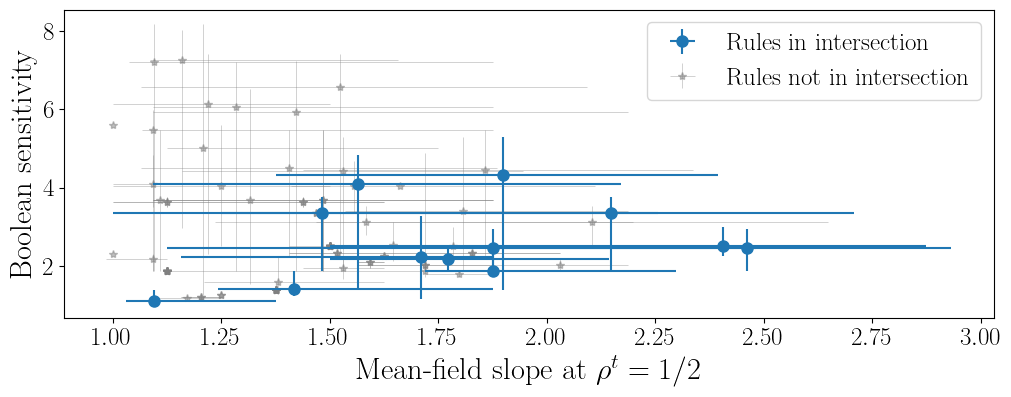

In [135]:
SAVEFIG = True

# create ax object
fig, ax = plt.subplots(1,1,figsize=(12,4))
fontsize = 22

ax.errorbar(mfs_medians_inner, bs_medians_inner,
            xerr=mfs_errors_inner, yerr=bs_errors_inner,
            fmt='o', color='C0', markersize=8,
            label='Rules in intersection', zorder=2)
ax.errorbar(mfs_medians_outer, bs_medians_outer,
            xerr=mfs_errors_outer, yerr=bs_errors_outer,
            fmt='*', color='grey', alpha=0.5, capsize=0, elinewidth=0.5,
            label='Rules not in intersection', zorder=1)
ax.legend(fontsize=fontsize-4)
ax.set_xlabel(fr'Mean-field slope at $\rho^t=1/2$', fontsize=fontsize)
ax.set_ylabel('Boolean sensitivity', fontsize=fontsize)
# ax.set_title(f"Degrees {degrees[0]} to {degrees[-1]}, resolution {resolution}, {len(mfs_list)} points", fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=fontsize-4)

if SAVEFIG:
    plt.savefig(figures_dir+f'mfs_vs_bs-totalitarian_rules_r{resolution}-degrees{degrees[0]}to{degrees[-1]}.pdf', bbox_inches='tight')

### Computational results

We should do the following very simple first thingie
- create a simple small small-world network from a grid with a fixed p value
- create some random initial configuration
- run this LLNA for all intersection rules of resolution 9
- track the normalised Shannon entropy over the subsequent time steps

In [4]:
# Parameters
L = 30                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast
rewiring_prob = 0.4     # Rewiring probability
mean_degree = 8
rewiring_prob = 0.4     # Rewiring probability
mean_degree = 8
num_graphs = 30

# Create toroidal lattice and rewire
lattice_graph = create_2d_torus_lattice(L, degree=mean_degree)
small_world_graphs = [watts_strogatz_rewire(lattice_graph, rewiring_prob) for _ in tqdm(range(num_graphs), total=num_graphs)]

# find edges for small world graph
small_world_edges_list = []
for small_world_graph in small_world_graphs:
    small_world_graph.to_directed()
    small_world_edges = tc.tensor(small_world_graph.get_edgelist()).T
    small_world_edges_list.append(small_world_edges)
    small_world_graph.to_undirected()

# bins = np.arange(0, max(small_world_graphs[0].degree()) + 2) - 0.5
# _=plt.hist(small_world_graphs[0].degree(), bins=bins, edgecolor='black', alpha=0.7)

  0%|          | 0/30 [00:00<?, ?it/s]

100%|██████████| 30/30 [00:02<00:00, 12.83it/s]


In [3]:
RUN_AGAIN = True

if RUN_AGAIN:

    # Parameters
    L = 30                  # Grid size (L x L) WATCH OUT with values, becomes intensive fast
    mean_degree = 4
    num_graphs = 30

    for rewiring_prob in [0.0, 0.4, 0.6, 0.8, 1.0]:

        print(f"Working on rewiring probability {rewiring_prob} ...")

        # Create toroidal lattice and rewire
        lattice_graph = create_2d_torus_lattice(L, degree=mean_degree)
        small_world_graphs = [watts_strogatz_rewire(lattice_graph, rewiring_prob) for _ in tqdm(range(num_graphs), total=num_graphs)]

        # find edges for small world graph
        small_world_edges_list = []
        for small_world_graph in small_world_graphs:
            small_world_graph.to_directed()
            small_world_edges = tc.tensor(small_world_graph.get_edgelist()).T
            small_world_edges_list.append(small_world_edges)
            small_world_graph.to_undirected()

        # bins = np.arange(0, max(small_world_graphs[0].degree()) + 2) - 0.5
        # _=plt.hist(small_world_graphs[0].degree(), bins=bins, edgecolor='black', alpha=0.7)

        num_nodes = L**2
        T = 100 # num_nodes // 10
        num_config = 30

        init_dens = .5
        p_str = f"{rewiring_prob:.2f}".replace('.', 'p')
        output_dir = os.path.join('data', 'impact_analysis', 'configs')
        os.makedirs(output_dir, exist_ok=True)
        base_filename = f"configs_resolution{resolution}_N{num_nodes}_k{mean_degree}_p{p_str}.h5"
        file_path = os.path.join(output_dir, base_filename)

        print(f"Running simulations for totalitarian rules at resolution {resolution} ...")
        # NOTE currently the set_union is defined for 4 \leq k \leq 12
        number_of_rules = len(set_union)
        with h5py.File(file_path, 'a') as f:
            for beta, sigma in tqdm(set_union, total=number_of_rules):
                B_set = binary_indices(beta)
                S_set = binary_indices(sigma)
                model = LLNA(resolution, B_set, S_set, iso=True)

                group_path = (
                    f"/r{resolution}beta{beta}sigma{sigma}"
                    f"/N{num_nodes}T{T}"
                )
                if group_path in f and len(f[group_path].keys()) > 0:
                    raise RuntimeError(f"Data already exists for {group_path}")
                group = f.require_group(group_path)
                group.attrs['L'] = L
                group.attrs['num_nodes'] = num_nodes
                group.attrs['T'] = T
                group.attrs['resolution'] = resolution
                group.attrs['beta'] = beta
                group.attrs['sigma'] = sigma
                group.attrs['init_dens'] = init_dens
                group.attrs['rewiring_prob'] = rewiring_prob
                group.attrs['mean_degree'] = mean_degree
                group.attrs['num_graphs'] = num_graphs
                group.attrs['num_config'] = num_config

                for graph_idx, small_world_edges in enumerate(small_world_edges_list):
                    graph_group = group.require_group(f"graph_{graph_idx:03d}")

                    # for each graph, make some random initial configurations with the given density
                    init_configs = np.array(
                        [init_config_with_dens(num_nodes, init_dens) for _ in range(num_config)],
                        dtype=np.uint8
                    )

                    # run simulation over a number of time steps
                    configs = model.forward(small_world_edges, tc.tensor(init_configs), T=T).numpy().astype(np.uint8)

                    # save edges and configs
                    edges_np = small_world_edges.cpu().numpy().astype(np.int32)
                    if 'edges' in graph_group:
                        raise RuntimeError(f"edges already exists in {graph_group.name}")
                    graph_group.create_dataset(
                        'edges',
                        data=edges_np,
                        compression='gzip',
                        compression_opts=4,
                        shuffle=True
                    )

                    if 'configs' in graph_group:
                        raise RuntimeError(f"configs already exists in {graph_group.name}")
                    graph_group.create_dataset(
                        'configs',
                        data=configs,
                        compression='gzip',
                        compression_opts=4,
                        shuffle=True
                    )

Working on rewiring probability 0.0 ...


100%|██████████| 30/30 [00:00<00:00, 10639.14it/s]


Running simulations for totalitarian rules at resolution 9 ...


  0%|          | 0/106 [00:00<?, ?it/s]

100%|██████████| 106/106 [10:40<00:00,  6.04s/it]


...

100%|██████████| 106/106 [11:52<00:00,  6.72s/it]


Working on rewiring probability 1.0 ...


100%|██████████| 30/30 [00:02<00:00, 13.55it/s]


Running simulations for totalitarian rules at resolution 9 ...


100%|██████████| 106/106 [11:51<00:00,  6.71s/it]


In [5]:
# Show all available data for a particular rule in a given HDF5 file
import glob

rule_beta = 488
rule_sigma = 464

configs_dir = os.path.join('data', 'impact_analysis', 'configs')
candidate_files = sorted(
    glob.glob(os.path.join(configs_dir, 'configs_resolution*_N*_k*_p*.h5')),
    key=os.path.getmtime
 )
if candidate_files:
    h5_path = candidate_files[-1]
else:
    raise FileNotFoundError(f'No configs files found in {configs_dir}')

rule_path = f"/r{resolution}beta{rule_beta}sigma{rule_sigma}"

def print_rule_tree(name, obj):
    indent = "  " * name.count('/')
    if isinstance(obj, h5py.Group):
        print(f"{indent}{name}/ (Group)")
    elif isinstance(obj, h5py.Dataset):
        print(f"{indent}{name} (Dataset) shape={obj.shape}, dtype={obj.dtype}")

with h5py.File(h5_path, 'r') as f:
    if rule_path not in f:
        raise KeyError(f"Rule not found: {rule_path}")
    rule_group = f[rule_path]
    print('H5 file:', h5_path)
    print('Rule group:', rule_path)
    print('Top-level attributes:', dict(rule_group.attrs))
    rule_group.visititems(print_rule_tree)

H5 file: data\impact_analysis\configs\configs_resolution9_N900_k4_p0p20.h5
Rule group: /r9beta488sigma464
Top-level attributes: {}
N900T100/ (Group)
  N900T100/graph_000/ (Group)
    N900T100/graph_000/configs (Dataset) shape=(30, 101, 900), dtype=uint8
    N900T100/graph_000/edges (Dataset) shape=(2, 3600), dtype=int32
  N900T100/graph_001/ (Group)
    N900T100/graph_001/configs (Dataset) shape=(30, 101, 900), dtype=uint8
    N900T100/graph_001/edges (Dataset) shape=(2, 3600), dtype=int32
  N900T100/graph_002/ (Group)
    N900T100/graph_002/configs (Dataset) shape=(30, 101, 900), dtype=uint8
    N900T100/graph_002/edges (Dataset) shape=(2, 3600), dtype=int32
  N900T100/graph_003/ (Group)
    N900T100/graph_003/configs (Dataset) shape=(30, 101, 900), dtype=uint8
    N900T100/graph_003/edges (Dataset) shape=(2, 3600), dtype=int32
  N900T100/graph_004/ (Group)
    N900T100/graph_004/configs (Dataset) shape=(30, 101, 900), dtype=uint8
    N900T100/graph_004/edges (Dataset) shape=(2, 3600)

In [7]:
# Stack configs across all graphs for a specific rule and N,T group
rule_beta = 488
rule_sigma = 464
target_num_nodes = num_nodes
target_T = T

if 'h5_path' not in globals():
    raise ValueError('h5_path not found. Run the tree cell first.')

group_path = (
    f"/r{resolution}beta{rule_beta}sigma{rule_sigma}"
    f"/N{target_num_nodes}T{target_T}"
 )

with h5py.File(h5_path, 'r') as f:
    if group_path not in f:
        raise KeyError(f"Group not found: {group_path}")
    group = f[group_path]
    graph_keys = sorted([k for k in group.keys() if k.startswith('graph_')])
    if not graph_keys:
        raise ValueError(f"No graph groups found in {group_path}")

    configs_list = []
    for graph_key in graph_keys:
        configs_list.append(group[graph_key]['configs'][:])

    stacked_configs = np.concatenate(configs_list, axis=0)
    entropy_per_sample = shannon_entropy(stacked_configs)
    print('Graphs:', len(graph_keys))
    print('Per-graph configs shape:', configs_list[0].shape)
    print('Stacked configs shape:', stacked_configs.shape)
    print('Entropy shape:', entropy_per_sample.shape)

Graphs: 30
Per-graph configs shape: (30, 101, 900)
Stacked configs shape: (900, 101, 900)
Entropy shape: (900, 101)


Interestingly, for $\langle k \rangle = 4$, not a single rule is found that moves the system towards a homogeneous state. Could it be that only the Watts rule (with a probabilitistic update at $\rho_i = 1/2$) moves the system towards homogeneity?

100%|██████████| 106/106 [00:57<00:00,  1.84it/s]


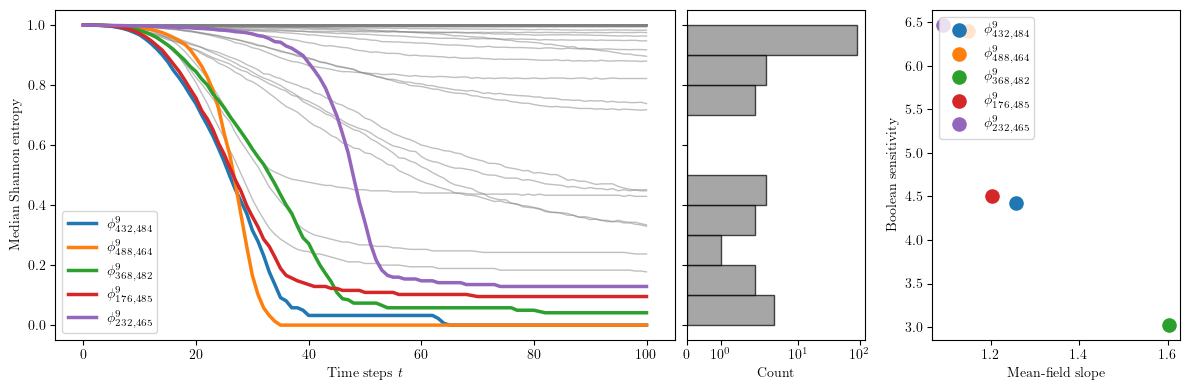

In [30]:
# TODO I should turn the scatter plot into an errorbar plot showing the range of values across degrees for each rule, instead of just the median

target_num_nodes = 900
target_T = 100
target_resolution = 9
target_degree = 8
target_p_str = '0p20'

n_best = 5

configs_dir = os.path.join('data', 'impact_analysis', 'configs')
configs_name = f'configs_resolution{target_resolution}_N{target_num_nodes}_k{target_degree}_p{target_p_str}.h5'
h5_path = os.path.join(configs_dir, configs_name)

rule_pattern = re.compile(r"^r(\d+)beta(\d+)sigma(\d+)$")

median_ts_by_rule = {}
final_median_by_rule = {}

with h5py.File(h5_path, 'r') as f:
    # recover the configuration time series for each rule
    for key in tqdm(f.keys(), total=len(f.keys())):
        match = rule_pattern.match(key)
        if not match:
            continue
        r_val, beta, sigma = (int(x) for x in match.groups())
        if r_val != target_resolution:
            continue
        group_path = f"/{key}/N{target_num_nodes}T{target_T}"
        if group_path not in f:
            continue
        group = f[group_path]
        graph_keys = sorted([k for k in group.keys() if k.startswith('graph_')])
        if not graph_keys:
            continue

        configs_list = [group[gk]['configs'][:] for gk in graph_keys]
        stacked_configs = np.concatenate(configs_list, axis=0)
        entropy_per_sample = shannon_entropy(stacked_configs)
        median_ts = np.median(entropy_per_sample, axis=0)

        rule = (beta, sigma)
        median_ts_by_rule[rule] = median_ts
        final_median_by_rule[rule] = median_ts[-1]

if not final_median_by_rule:
    raise ValueError('No matching rule data found for the selected N and T.')

sorted_rules = sorted(final_median_by_rule.items(), key=lambda x: x[1])
best_rules = [rule for rule, _ in sorted_rules[:n_best]]

# Compute BS and slope for best rules for the target_degree
# TODO this is currently just the mean degree of the network, which is not right
bs_vals = []
slope_vals = []
for beta, sigma in best_rules:
    B_set = binary_indices(beta)
    S_set = binary_indices(sigma)
    bs_vals.append(boolean_sens(target_resolution, B_set=B_set, S_set=S_set, degree=target_degree))
    slope_vals.append(mean_field_slope(target_resolution, B_set=B_set, S_set=S_set, degree=target_degree))

# Plot
fig = plt.figure(figsize=(12, 4))
gs = fig.add_gridspec(1, 3, width_ratios=[5, 1, 2])
ax_left = fig.add_subplot(gs[0])
ax_mid = fig.add_subplot(gs[1], sharey=ax_left)
ax_right = fig.add_subplot(gs[2])

# Left: all rules in gray
for rule, median_ts in median_ts_by_rule.items():
    ax_left.plot(range(len(median_ts)), median_ts, color='gray', alpha=0.5, lw=1)

# Highlight best rules
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i, rule in enumerate(best_rules):
    label = fr'$\phi^{{{target_resolution}}}_{{{rule[0]},{rule[1]}}}$'
    ax_left.plot(range(len(median_ts_by_rule[rule])), median_ts_by_rule[rule],
                 color=colors[i % len(colors)], lw=2.5, label=label)

ax_left.set_xlabel(r'Time steps $t$')
ax_left.set_ylabel('Median Shannon entropy')
ax_left.legend(frameon=True, fontsize=10, loc='lower left')

# Middle: histogram of final median entropies
final_vals = np.array(list(final_median_by_rule.values()))
ax_mid.hist(final_vals, bins=10, orientation='horizontal', color='gray', alpha=0.7, edgecolor='black')
ax_mid.set_xlabel('Count')
ax_mid.tick_params(axis='y', labelleft=False)
ax_mid.set_xscale('symlog')

# Right: BS vs slope for best rules
for i, rule in enumerate(best_rules):
    label = fr'$\phi^{{{target_resolution}}}_{{{rule[0]},{rule[1]}}}$'
    ax_right.scatter(slope_vals[i], bs_vals[i], s=90, color=colors[i % len(colors)], label=label)

ax_right.set_xlabel('Mean-field slope')
ax_right.set_ylabel('Boolean sensitivity')
ax_right.legend(frameon=True, fontsize=10, loc='upper left')

plt.tight_layout()

# Tighten the gap between left and middle axes
pos_left = ax_left.get_position()
pos_mid = ax_mid.get_position()
gap = 0.01
new_mid_x0 = pos_left.x1 + gap
new_mid_width = pos_mid.x1 - new_mid_x0
ax_mid.set_position([new_mid_x0, pos_mid.y0, new_mid_width, pos_mid.height])

plt.show()

- Wat is er nu speciaal aan de regels die goeie resultaten opleveren?
- Kan ik nog een andere metriek gebruiken, zoals _edge disagreement_, _assortativity_, _normalised mutual information_?
- Hoe zit dit voor een andere gemiddelde degree?
- Voor degree 8 is het duidelijk dat $\phi^9_{488,464}$ het weer goed doet
- Voor degree 4 gaat er geen enkele gemiddeld consistent naar 0, maar zien we wel dat er andere regels heel anders reageren.
- In plaats van gemiddelden te bekijken, moet ik ook eens de interquartile range bestuderen, want we willen wel regels die consequent een vrij goed resultaat geven.

voor k=8, p=0.2: `[(488, 464), (432, 484), (232, 465), (176, 485), (336, 490)]`

voor k=4, p=0.2: `[(240, 481), (112, 483), (432, 484), (304, 486), (48, 487)]`

## Structural ranking

- Focus on rule 488,464
- Create 30 networks with 30 initial configurations each
- Check how many go to a totalitarian end state

In [31]:
import h5py
from pathlib import Path

num_nodes = 900
mean_degree = 8
T = 100
p = 0.2
p_string = f"{p:.2f}".replace('.', 'p')

resolution = 9
beta = 488
sigma = 464

h5_path = Path(f"data/impact_analysis/configs/configs_resolution{resolution}_N{num_nodes}_k{mean_degree}_p{p_string}.h5")
rule_group_path = f"r{resolution}beta{beta}sigma{sigma}/N{num_nodes}T{T}"

rule_488_464 = {}
with h5py.File(h5_path, "r") as f:
    group = f[rule_group_path]
    num_graphs = group.attrs["num_graphs"]
    num_config = group.attrs.get("num_config")
    for graph_key in sorted(group.keys()):
        graph_group = group[graph_key]
        rule_488_464[graph_key] = {
            "configs": graph_group["configs"][:],
            "edges": graph_group["edges"][:],
        }

counter = 0
for graph_key, data in rule_488_464.items():
    # get all configs for this graph
    configs = data["configs"]
    # get all final configurations
    final_configs = configs[:, -1, :]
    # get the max and min value for each sample in the final configurations
    max_final = np.max(final_configs, axis=1)
    min_final = np.min(final_configs, axis=1)
    # count how many times the max is 0 and the min is 1
    count_max_0 = np.sum(max_final == 0)
    count_min_1 = np.sum(min_final == 1)
    # add this to the counter
    counter += count_max_0 + count_min_1

print("Fraction of converged initial configurations for rule (488, 464):")
print(counter / num_graphs / num_config)

Fraction of converged initial configurations for rule (488, 464):
0.9622222222222222


In [ ]:
top_fraction = 0.05
top_index_cutoff = int(num_nodes * top_fraction)

# make empty lists to store the fractions for each centrality measure
fractions_degrees = []
fractions_avg_neigh_degree = []
fractions_h_index = []
fractions_eigenvector = []
fractions_betweenness = []
fractions_closeness = []

for graph_key, data in tqdm(rule_488_464.items(), total=len(rule_488_464.items())):
    # load configs and edges
    configs = data["configs"]
    edges = data["edges"]
    # create undirected igraph graph from edges
    g = ig.Graph(n=num_nodes, edges=edges.T.tolist(), directed=True)
    g = g.as_undirected(combine_edges=False)
    # get centrality measures
    degrees = g.degree()
    avg_neigh_degree = g.knn()[0]
    h_index = node_h_indices(g)
    eigenvector = g.eigenvector_centrality()
    betweenness = g.betweenness()
    closeness = g.closeness()
    # look at state of final configurations
    final_configs = configs[:,-1,:]
    max_finals = np.max(final_configs, axis=1)
    min_finals = np.min(final_configs, axis=1)
    # run over all simulations
    for max_final, min_final, init_configs in zip(max_finals, min_finals, configs[:, 0, :]):
        # check whether it converged to all 0s
        if max_final == 0:
            # calculate the fraction of begin states that match the global end state
            fraction_degrees = np.mean(init_configs[np.argsort(degrees)[-top_index_cutoff:]]==max_final)
            fraction_avg_neigh_degree = np.mean(init_configs[np.argsort(avg_neigh_degree)[-top_index_cutoff:]]==max_final)
            fraction_h_index = np.mean(init_configs[np.argsort(h_index)[-top_index_cutoff:]]==max_final)
            fraction_eigenvector = np.mean(init_configs[np.argsort(eigenvector)[-top_index_cutoff:]]==max_final)
            fraction_betweenness = np.mean(init_configs[np.argsort(betweenness)[-top_index_cutoff:]]==max_final)
            fraction_closeness = np.mean(init_configs[np.argsort(closeness)[-top_index_cutoff:]]==max_final)
            # append to lists
            fractions_degrees.append(fraction_degrees)
            fractions_avg_neigh_degree.append(fraction_avg_neigh_degree)
            fractions_h_index.append(fraction_h_index)
            fractions_eigenvector.append(fraction_eigenvector)
            fractions_betweenness.append(fraction_betweenness)
            fractions_closeness.append(fraction_closeness)
        # check whether it converged to all 1s
        if min_final == 1:
            # calculate the fraction of begin states that match the global end state
            fraction_degrees = np.mean(init_configs[np.argsort(degrees)[-top_index_cutoff:]]==min_final)
            fraction_avg_neigh_degree = np.mean(init_configs[np.argsort(avg_neigh_degree)[-top_index_cutoff:]]==min_final)
            fraction_h_index = np.mean(init_configs[np.argsort(h_index)[-top_index_cutoff:]]==min_final)
            fraction_eigenvector = np.mean(init_configs[np.argsort(eigenvector)[-top_index_cutoff:]]==min_final)
            fraction_betweenness = np.mean(init_configs[np.argsort(betweenness)[-top_index_cutoff:]]==min_final)
            fraction_closeness = np.mean(init_configs[np.argsort(closeness)[-top_index_cutoff:]]==min_final)
            # append to lists
            fractions_degrees.append(fraction_degrees)
            fractions_avg_neigh_degree.append(fraction_avg_neigh_degree)
            fractions_h_index.append(fraction_h_index)
            fractions_eigenvector.append(fraction_eigenvector)
            fractions_betweenness.append(fraction_betweenness)
            fractions_closeness.append(fraction_closeness)


100%|██████████| 30/30 [00:04<00:00,  6.51it/s]


(array([  0.,   0.,   0.,  19., 199., 195.,  21.,   1.,   0.,   0.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

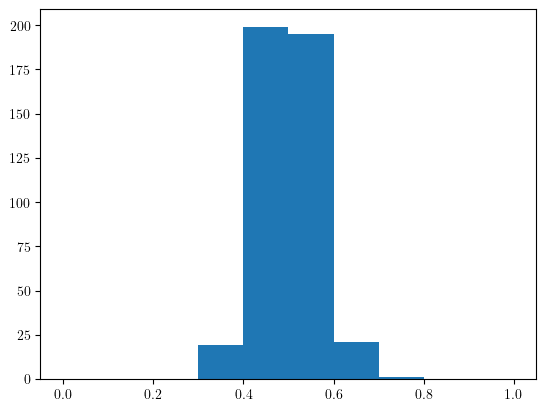

In [99]:
bins = np.linspace(0, 1, 11)
plt.hist(fractions_betweenness, bins=bins)

Esssentially the conclusion here is that there is little correlation, I think. In a sense, that's pretty weird.

In [119]:
max_switches = 45
number_of_switches_array = np.arange(1,max_switches+1, dtype=int)
kill_low_values = True

init_config_stack = init_configs.copy()
for number_of_switches in tqdm(number_of_switches_array, total=max_switches):
    init_config_switched = switch_life_to_higher_node_property_values(np.array(degrees), init_configs, number_of_switches, kill_low_values=kill_low_values)
    init_config_stack = np.vstack((init_config_stack, init_config_switched))

100%|██████████| 45/45 [00:00<00:00, 2026.26it/s]


(<Figure size 1000x180 with 1 Axes>,
 <Axes: title={'center': 'Diagram for LLNA $\\phi^{9}_{488,464}$'}, xlabel="State density $\\rho$ of the node's neighbourhood", ylabel='Node becomes ...'>)

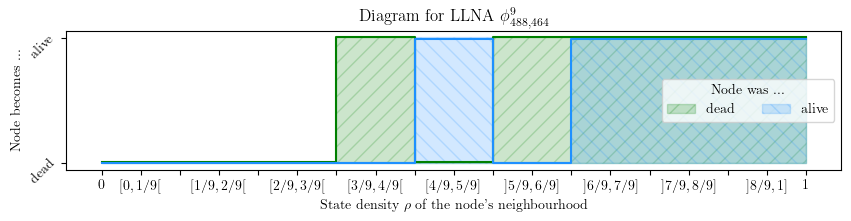

In [126]:
beta = 488
sigma = 464

B_set = binary_indices(beta)
S_set = binary_indices(sigma)

model = LLNA(resolution, B_set, S_set, iso=True)
model.diagram()

In [127]:
max_number_switches = 3
number_of_switches_array = np.arange(1, max_number_switches + 1, dtype=int)

end_state_switches_degrees = []
for _, data in tqdm(rule_488_464.items(), total=len(rule_488_464.items())):
    # load configs and edges
    configs = data["configs"]
    edges_igraph = data["edges"].T.tolist()
    # recreate undirected igraph graph from edges
    g = ig.Graph(n=num_nodes, edges=edges_igraph, directed=True)
    edges_forward = tc.tensor(g.get_edgelist()).T
    g = g.as_undirected(combine_edges=False)
    # get centrality measures
    degrees = np.array(g.degree())
    avg_neigh_degree = np.array(g.knn()[0])
    h_index = np.array(node_h_indices(g))
    eigenvector = np.array(g.eigenvector_centrality())
    betweenness = np.array(g.betweenness())
    closeness = np.array(g.closeness())
    # look at state of final configurations
    final_configs = configs[:,-1,:]
    max_finals = np.max(final_configs, axis=1)
    min_finals = np.min(final_configs, axis=1)
    # run over all simulations for this graph
    for max_final, min_final, init_configs in zip(max_finals, min_finals, configs[:, 0, :]):
        # check whether it converged to all 0s
        if max_final == 0: # it died out completely
            init_configs_stack = init_configs.copy()
            # create samples with switched values
            for number_of_switches in number_of_switches_array:
                init_configs_switched = switch_life_to_higher_node_property_values(degrees, init_configs, number_of_switches, kill_low_values=True)
                init_configs_stack = np.vstack((init_configs_stack, init_configs_switched))
            # run the model on the switched initial configurations
            configs = model.forward(edges_forward, tc.tensor(init_configs_stack), T=T).numpy().astype(np.uint8)
            continue
        # check whether it converged to all 1s
        if min_final == 1: # it is fully activated
            continue


# switch_life_to_higher_node_property_values(np.array(degrees), init_configs, 45)

100%|██████████| 30/30 [03:53<00:00,  7.77s/it]
